# Telco Customer Churn Prediction

This is my churn analysis project. Goal is to predict which customers are likely to leave (churn) using their account and service details, so the business could act early to retain them. This is a classification problem (churn yes/no), not regression like my last project.

Dataset: Telco-Customer-Churn.csv (7043 customers, 21 columns).

## Imports and loading data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
import shap
import joblib

pd.set_option("display.max_columns", None)

C:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


7043 rows, 21 columns.

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

no nulls showing up here, but I already suspected TotalCharges might have hidden blank strings since it's supposed to be numeric but pandas is treating it as text.

In [7]:
print((len(df[df['Churn']=='Yes'])/len(df))*100)

26.536987079369588


about 26.5% of customers churned. so this is an imbalanced classification problem - roughly 3.7 non-churners for every 1 churner. accuracy alone won't be a good metric here, need precision/recall/roc-auc.

## Cleaning TotalCharges

In [8]:
df['TotalCharges'].tail(10)

7033    2625.25
7034    6886.25
7035     1495.1
7036      743.3
7037     1419.4
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, dtype: str

dtype shows as object even though it looks numeric - confirms my suspicion.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


converting to numeric with errors='coerce' turned the bad values into NaN, and I can see exactly which rows - 11 rows, and every single one of them has tenure=0. makes sense - these are brand new customers who haven't been billed a full cycle yet, so TotalCharges was blank in the original data (probably represented as empty string).

In [10]:
df['TotalCharges'] = df['TotalCharges'].replace(np.nan, 0)
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

filled those 11 with 0 since a tenure=0 customer genuinely has 0 total charges so far, not a missing value to impute with mean/median.

In [11]:
df['customerID'].duplicated().sum()

np.int64(0)

0 duplicates, so each row is a unique customer.

## EDA (checking what relates to churn)

In [12]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
contract_churn = pd.crosstab(index=df["Churn"], columns=df["Contract"], normalize='columns')*100
contract_churn.round(1)

Contract,Month-to-month,One year,Two year
Churn,,,
No,57.3,88.7,97.2
Yes,42.7,11.3,2.8


huge finding - month-to-month contracts churn at 42.7%, but one-year contracts only 11.3% and two-year only 2.8%. contract type looks like a massive predictor.

In [14]:
tenure_churn = df.groupby('Churn')['tenure'].mean()
tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

customers who stayed have average tenure of 37.6 months, customers who churned only averaged 18 months. so newer customers churn more - makes sense, people who've been around longer are more locked in / satisfied.

In [15]:
monthycharges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
monthycharges_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

churned customers pay more on average (74.44 vs 61.27). interesting - so its not that cheap customers leave, its actually the opposite, higher paying customers churn more. probably tied to fiber optic customers paying more (checking that next).

In [16]:
internetservice_churn = pd.crosstab(index=df['Churn'], columns=df['InternetService'], normalize='columns')*100
internetservice_churn.round(1)

InternetService,DSL,Fiber optic,No
Churn,,,
No,81.0,58.1,92.6
Yes,19.0,41.9,7.4


confirmed - fiber optic customers churn at 41.9%, way higher than DSL (19%) or no internet (7.4%). fiber optic is probably pricier and maybe has more service issues, driving churn up even though it costs more.

In [17]:
paymentmethod_churn = pd.crosstab(index=df['Churn'], columns=df['PaymentMethod'], normalize='columns')*100
paymentmethod_churn.round(1)

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,83.3,84.8,54.7,80.9
Yes,16.7,15.2,45.3,19.1


electronic check payers churn at 45.3%, way higher than the other 3 payment methods (all around 15-19%). electronic check seems like a red flag category on its own.

In [18]:
seniorciti_churn = pd.crosstab(index=df['Churn'], columns=df['SeniorCitizen'], normalize='columns')*100
seniorciti_churn.round(1)

SeniorCitizen,0,1
Churn,,
No,76.4,58.3
Yes,23.6,41.7


senior citizens churn more (41.7%) compared to non-seniors (23.6%).

In [19]:
contract_internetservice = pd.crosstab(index=df['Contract'], columns=df['InternetService'])
contract_internetservice

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,1223,2128,524
One year,570,539,364
Two year,628,429,638


just checking how contract type and internet service relate to each other structurally, not to churn directly here.

### Visualizations

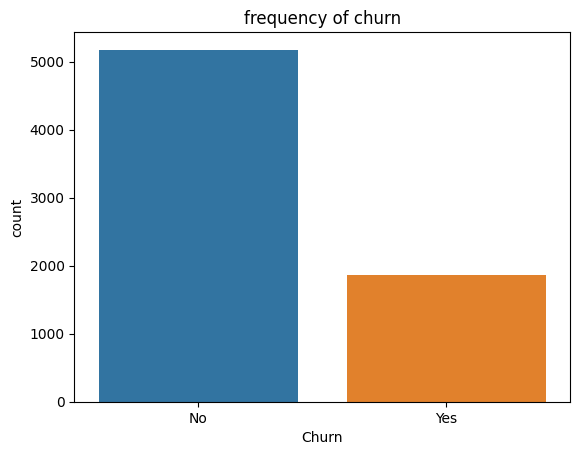

In [20]:
sns.countplot(data=df, x='Churn', hue='Churn')
plt.title("frequency of churn")
plt.savefig("number_of_churn.png")
plt.show()

visual confirmation of the 73.5/26.5 imbalance i calculated earlier.

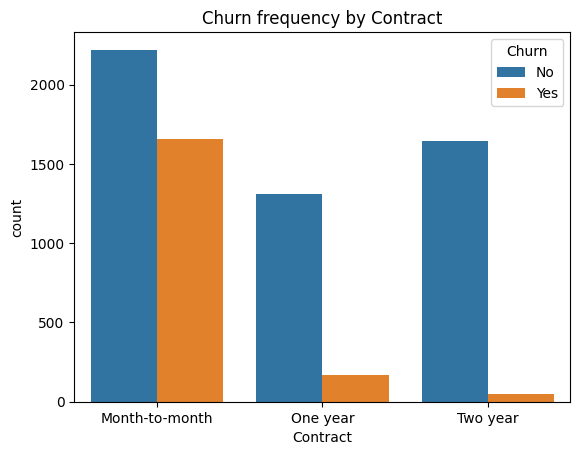

In [21]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn frequency by Contract")
plt.savefig("churn_frequency_by_contract.png")
plt.show()

visual version of the contract_churn crosstab - month-to-month has both the most customers AND the highest churn proportion, so this is where most of the actual churned customers live.

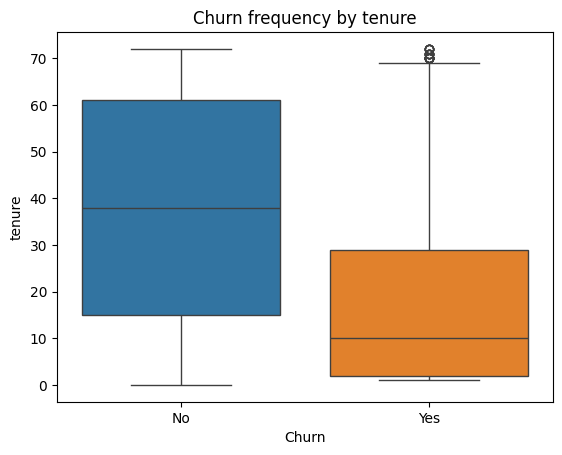

In [22]:
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn')
plt.title('Churn frequency by tenure')
plt.savefig("churn_frequency_by_tenure.png")
plt.show()

boxplot version of the tenure_churn groupby - churned customers box sits much lower (shorter tenure) than the stayed group.

In [23]:
corr_matrix = df[['MonthlyCharges', 'TotalCharges', 'tenure']]
corr_matrix.corr()

,MonthlyCharges,TotalCharges,tenure
MonthlyCharges,1.000000,0.651174,0.247900
TotalCharges,0.651174,1.000000,0.826178
tenure,0.247900,0.826178,1.000000


TotalCharges correlates strongly with tenure (0.826) which makes total sense - the longer you stay, the more total charges accumulate, its basically tenure x monthly rate. good to know for later - these two might be somewhat redundant as predictors.

In [24]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

churned customers have lower average TotalCharges (1531.8) than stayed customers (2549.9) - but this is likely just because churned customers left earlier (shorter tenure), not because they were low spenders.

### Binning tenure into categories

In [25]:
bin_div = np.linspace(df['tenure'].min(), df['tenure'].max(), 5)
bin_names = ['New', 'Early', 'Established', 'Long-term']
df['tenure-bins'] = pd.cut(df['tenure'], bins=bin_div, labels=bin_names, include_lowest=True)
tenure_catogary_churn = pd.crosstab(index=df["Churn"], columns=df["tenure-bins"], normalize='columns')*100
tenure_catogary_churn.round(1)

tenure-bins,New,Early,Established,Long-term
Churn,,,,
No,55.6,77.3,82.0,92.0
Yes,44.4,22.7,18.0,8.0


clean step-down pattern: New customers churn 44.4% of the time, Early 22.7%, Established 18%, Long-term only 8%. tenure is clearly one of the strongest churn signals in this whole dataset.

### Quick checks on gender and paperless billing

In [26]:
test_rel_gender_churn = pd.crosstab(index=df['gender'], columns=df['Churn'], normalize='index')
test_rel_PaperlessBilling_churn = pd.crosstab(index=df['PaperlessBilling'], columns=df['Churn'], normalize='index')
print(test_rel_gender_churn.round(2))
print(test_rel_PaperlessBilling_churn.round(2))

Churn     No   Yes
gender            
Female  0.73  0.27
Male    0.74  0.26
Churn               No   Yes
PaperlessBilling            
No                0.84  0.16
Yes               0.66  0.34


gender barely matters (73/27 vs 74/26, basically identical) - not a useful predictor. but paperless billing does show a gap - customers with paperless billing churn 34% of the time vs only 16% for non-paperless. worth keeping as a feature.

## Encoding the target and preparing features

In [27]:
dum_churn = pd.get_dummies(df['Churn'], drop_first=True, dtype=int)
df = pd.concat([df, dum_churn], axis=1)
df['Yes'].value_counts()

Yes
0    5174
1    1869
Name: count, dtype: int64

turned Churn (Yes/No text) into a proper 0/1 column. 5174 stayed (0), 1869 churned (1) - matches my earlier 26.5% calculation.

In [28]:
encode = ['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity',
          'OnlineBackup','DeviceProtection','TechSupport','StreamingMovies','StreamingTV','Contract',
          'PaperlessBilling','PaymentMethod']
do_standard = ['TotalCharges', 'MonthlyCharges', 'tenure']
df = df.rename(columns={'Yes': 'churn_yes'})

X = df[encode + do_standard]
Y = df['churn_yes']

split my columns into two groups - categorical columns that need one-hot encoding, and numeric columns that need scaling. renamed the dummy column to churn_yes so it's clearer than just 'Yes'.

## Train/Test split and preprocessing pipeline

In [29]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(x_train.shape, x_test.shape)

(5634, 18) (1409, 18)


used stratify=Y this time (didn't do this in my last regression project) - since churn is imbalanced (26.5%), stratify makes sure both train and test sets keep that same 26.5% churn ratio, instead of a random split accidentally putting more/fewer churners in one set by chance. 5634 train rows, 1409 test rows.

In [30]:
num_trans = StandardScaler()
cat_encode = OneHotEncoder(handle_unknown='ignore')
preprocess = ColumnTransformer(transformers=[('num', num_trans, do_standard), ('cat', cat_encode, encode)])
learned_transformed_xtrain = preprocess.fit_transform(x_train)
trans_xtest = preprocess.transform(x_test)

used ColumnTransformer to apply StandardScaler only to the numeric columns and OneHotEncoder only to the categorical columns, all in one step instead of doing them separately like I did dummy encoding manually in my last project. handle_unknown='ignore' on the encoder so it doesn't break if the test set has a category value it didn't see in training.

## Baseline model: Logistic Regression

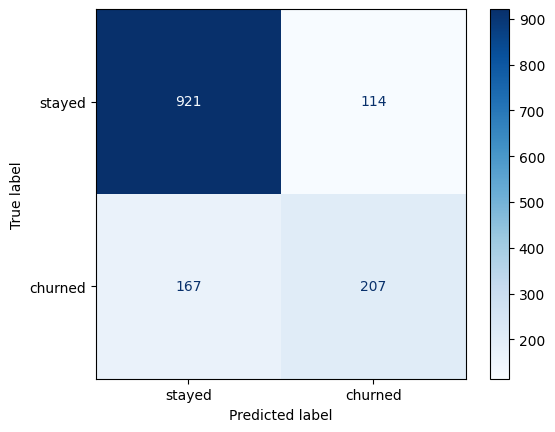

In [31]:
model = LogisticRegression()
model.fit(learned_transformed_xtrain, y_train)
y_pred = model.predict(trans_xtest)
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(cm, display_labels=['stayed','churned'])
display.plot(cmap='Blues')
plt.savefig("confusion_matrix.png")
plt.show()

confusion matrix at default 0.5 threshold: [[921, 114], [167, 207]]. so 921 correctly predicted as stayed, 207 correctly predicted as churned, but 167 actual churners got missed (predicted as stayed) and 114 false alarms.

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



accuracy 0.80 looks decent at first glance, but look closer at class 1 (churned) - precision 0.64, recall only 0.55. this means the model is missing almost half the actual churners (45% of them slip through). this is exactly the accuracy-is-misleading problem with imbalanced data - overall accuracy looks fine but the minority class (the one that actually matters for the business) is underperforming.

## Trying tree-based models

In [33]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(learned_transformed_xtrain, y_train)
y_pred_rf = rf_model.predict(trans_xtest)
print(y_pred_rf[:10])
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[0 1 0 0 0 0 0 0 0 0]
0.7785663591199432
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



random forest accuracy 0.779, actually slightly worse than logistic regression (0.80), and recall for churned class is even lower (0.47 vs logistic's 0.55). random forest didn't beat the simpler model here - good example of more complex not always being better, especially out of the box without tuning.

In [34]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(learned_transformed_xtrain, y_train)
gb_model_pred = gb_model.predict(trans_xtest)
print(classification_report(y_test, gb_model_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



gradient boosting: accuracy 0.80, precision 0.67 and recall 0.53 for churned class - slightly better precision than logistic regression but similar recall. still missing about half the churners at default threshold. logistic regression is holding up surprisingly well against both tree models here.

## Feature importance (logistic regression coefficients)

In [35]:
feature_names = preprocess.get_feature_names_out()
ls_model_coef = model.coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': ls_model_coef})
coef_df = coef_df.sort_values('coefficient', ascending=False)
top_fea = coef_df.head(10)
bot_fea = coef_df.tail(10)
imp_fea = pd.concat([top_fea, bot_fea])
imp_fea

,feature,coefficient
15,cat__InternetService_Fiber optic,0.653463
35,cat__Contract_Month-to-month,0.588335
0,num__TotalCharges,0.532165
31,cat__StreamingMovies_Yes,0.207122
34,cat__StreamingTV_Yes,0.206516
42,cat__PaymentMethod_Electronic check,0.203886
17,cat__OnlineSecurity_No,0.158227
26,cat__TechSupport_No,0.137927
13,cat__MultipleLines_Yes,0.109781
20,cat__OnlineBackup_No,0.033946


top positive coefficients (push churn probability UP): Fiber optic internet (0.65), Month-to-month contract (0.59), TotalCharges (0.53), StreamingMovies/StreamingTV Yes, Electronic check payment, OnlineSecurity No, TechSupport No.

top negative coefficients (push churn probability DOWN): tenure (-1.25, biggest effect in the whole model), Two year contract (-0.78), DSL internet (-0.66), MonthlyCharges (-0.61), PaperlessBilling No (-0.35).

this matches everything I found in EDA - tenure and contract length are the two strongest retention factors, fiber optic and electronic check are the two strongest churn risk factors.

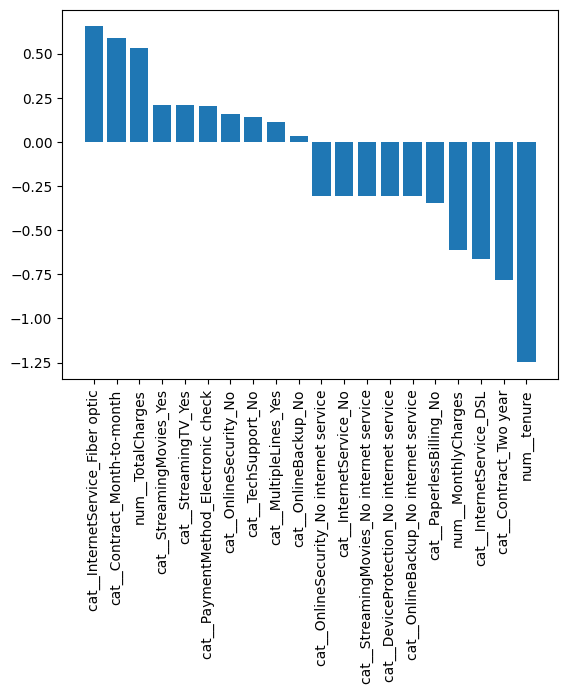

In [36]:
plt.bar(imp_fea['feature'], imp_fea['coefficient'])
plt.xticks(rotation=90)
plt.show()

## Threshold tuning

default classifier threshold is 0.5, but since I care more about catching actual churners (recall) even at the cost of some false alarms, I tested lowering the threshold to see the tradeoff.

In [37]:
mag_model = model.predict_proba(trans_xtest)[:,1]
mag_035 = (mag_model >= 0.35).astype(int)
print("0.35\n", classification_report(y_test, mag_035))

0.35
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



at 0.35 threshold: churned recall jumps to 0.71 (from 0.55 at default), but precision drops to 0.55 (from 0.64). catching way more real churners now, at the cost of more false alarms.

In [38]:
mag_030 = (model.predict_proba(trans_xtest)[:,1] >= 0.30).astype(int)
print("0.30\n", classification_report(y_test, mag_030))

0.30
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



at 0.30: recall goes even higher to 0.75, precision drops further to 0.52.

In [39]:
mag_045 = (model.predict_proba(trans_xtest)[:,1] >= 0.45).astype(int)
print("0.45\n", classification_report(y_test, mag_045))

0.45
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      1035
           1       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



at 0.45: more balanced, recall 0.62, precision 0.60.

In [40]:
mag_040 = (model.predict_proba(trans_xtest)[:,1] >= 0.40).astype(int)
print("0.40\n", classification_report(y_test, mag_040))

0.40
               precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



at 0.40: recall 0.67, precision 0.57.

comparing all of them, I went with 0.35 as my chosen threshold - a telecom business retention team would rather flag more at-risk customers (even some false positives means a wasted retention offer, which is cheap) than silently lose real customers (a missed churner is a lost customer, way more expensive). this is a business call, not just a technical one.

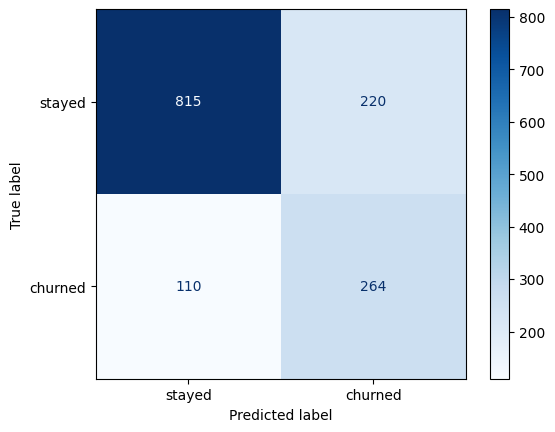

In [41]:
final_cm = confusion_matrix(y_test, mag_035)
display_final_cm = ConfusionMatrixDisplay(final_cm, display_labels=["stayed","churned"])
display_final_cm.plot(cmap='Blues')
plt.savefig("final_confusion_matrix_for_best_threshold.png")
plt.show()

at 0.35 threshold: [[815, 220], [110, 264]]. compared to default 0.5 threshold ([[921,114],[167,207]]) - I'm now catching 264 churners instead of 207 (57 more caught), at the cost of 220 false alarms instead of 114 (106 more false alarms). that tradeoff makes sense given the business reasoning above.

## Wrapping preprocessing + model into one final Pipeline

In [42]:
final_model = Pipeline([('preprocess', preprocess), ('model', LogisticRegression())])
final_model.fit(x_train, y_train)
final_prob = final_model.predict_proba(x_test)[:,1]
final_predict = (final_prob >= 0.35).astype(int)
print(classification_report(y_test, final_predict))
print(roc_auc_score(y_test, final_prob))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

0.8407321294789325


wrapped preprocessing and the model into one Pipeline object so I don't have to manually transform train/test separately every time - same lesson I learned in my regression project about why pipelines matter for cross-validation. numbers match my manual threshold-0.35 run exactly, good consistency check. ROC-AUC score is 0.841 - since this is threshold-independent, it tells me the model separates churners from non-churners fairly well overall, regardless of which cutoff I pick.

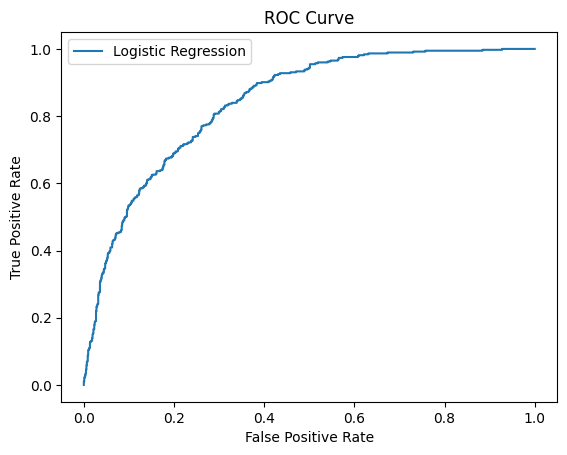

In [43]:
fpr, trp, threshold = roc_curve(y_test, final_prob)
plt.plot(fpr, trp, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

ROC curve bows nicely above the diagonal (which would represent random guessing) - visual confirmation of that 0.841 AUC score.

## Cross-validation

In [44]:
scores = cross_val_score(final_model, x_train, y_train, cv=5, scoring='roc_auc')
print(scores)
print(scores.mean())

[0.86441924 0.85376779 0.85115441 0.8355024  0.82392133]
0.8457530354634928


5-fold cross validated ROC-AUC: [0.864, 0.854, 0.851, 0.836, 0.824], mean 0.846. close to my single-split score of 0.841, so that wasn't just a lucky split - the model genuinely separates classes well and consistently across folds.

## Trying class_weight='balanced' as an alternative to threshold tuning

In [45]:
balanced_model = Pipeline([('preprocess', preprocess), ('model', LogisticRegression(class_weight='balanced'))])
balanced_model.fit(x_train, y_train)
balanced_model_pred = balanced_model.predict(x_test)
print(classification_report(y_test, balanced_model_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



this is a different approach to the imbalance problem than manual threshold tuning - class_weight='balanced' tells the model itself to weigh the minority class more heavily during training, using the default 0.5 threshold. result: recall for churned jumps to 0.78 (even higher than my manual 0.35 threshold's 0.71), but precision drops to 0.50. so this pushes even further toward catching churners at the cost of more false alarms. good to have both techniques in my toolkit - threshold tuning gives finer control, class_weight is a simpler one-line alternative.

## SHAP explainability

In [46]:
preprocesing = final_model.named_steps['preprocess']
x_test_transformed = preprocesing.transform(x_test)
real_model = final_model.named_steps['model']
explainer = shap.LinearExplainer(real_model, x_test_transformed)
shap_values = explainer.shap_values(x_test_transformed)

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


used shap.LinearExplainer directly this time since logistic regression is a linear model - remembered from my last project that shap.Explainer()'s auto-detection can be inconsistent with models buried inside a Pipeline, so I extracted the fitted model and the already-transformed test data manually first, same fix I eventually needed (but ran out of time for) on my last project's Ridge pipeline.

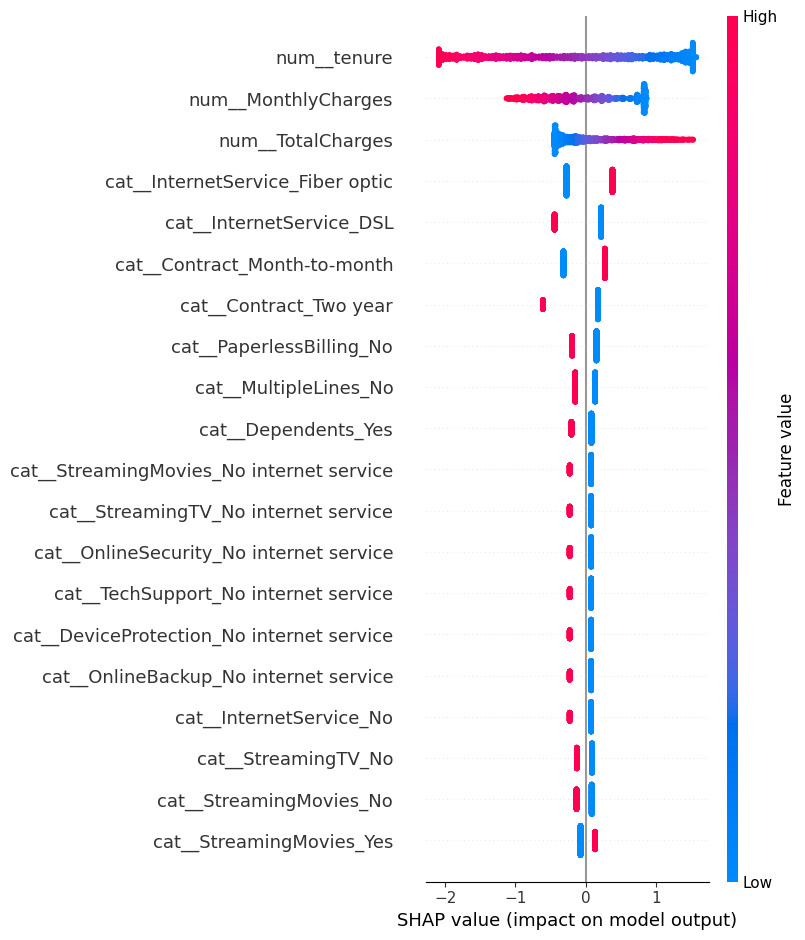

<Figure size 640x480 with 0 Axes>

In [47]:
shap.summary_plot(shap_values, x_test_transformed, feature_names=feature_names)
plt.savefig("shap_summary.png")

summary plot lines up with my logistic regression coefficients from Step 8 - tenure and contract type dominate, fiber optic and electronic check push risk up. good confirmation that the coefficient-based feature importance and SHAP are telling the same story here, which makes sense since this is a linear model - SHAP mainly adds the per-customer, individual-level explanation on top.

## Saving the final model

In [48]:
joblib.dump(final_model, 'churn_model.pkl')
loaded_model = joblib.load('churn_model.pkl')

saved the final pipeline (preprocessing + logistic regression) with joblib, so I can load it into a separate app for deployment without retraining.

## Summary

- Churn rate: 26.5% (imbalanced classification problem)
- Strongest churn drivers: low tenure, month-to-month contracts, fiber optic internet, electronic check payment
- Strongest retention factors: long tenure, two-year contracts, DSL/no internet, non-electronic-check payment
- Best model: Logistic Regression (simple model held up better than Random Forest and Gradient Boosting out of the box)
- ROC-AUC: 0.841 (single split), 0.846 (5-fold cross-validated)
- Chosen decision threshold: 0.35 (prioritizing recall over precision, since missing a real churner is costlier to the business than a false alarm)
- Added SHAP for per-customer explainability, saved the final pipeline with joblib for deployment

